# Module 15 Week 17 Required Assignment


## 1. Deep Learning vs. Traditional Machine Learning

Traditional machine learning (e.g. logistic regression, decision trees, k-NN) relies heavily on **manual feature engineering** — a human has to decide which features (e.g. pixel edges, TF-IDF word counts, hand-picked ratios) the model should look at, then a relatively simple model learns a mapping from those features to an output. It works well on **structured, tabular data** and needs comparatively little data and compute.

Deep learning (e.g. CNNs, RNNs/LSTMs, Transformers) uses many stacked layers that **learn their own feature representations directly from raw, unstructured data** such as images, audio and text, removing the need for manual feature extraction. This makes it excel at unstructured data, but it typically needs **much larger datasets** and **significantly higher computational cost** (GPUs/TPUs, long training times) than traditional ML, and the learned features are harder to interpret.


## 2. LSTM Networks in NLP

A plain RNN processes a sequence step by step, feeding its hidden state forward, but during backpropagation through many time steps its gradients tend to **vanish (or explode)**, so it effectively "forgets" information from far earlier in the sequence — it struggles with **long-range dependencies** (e.g. remembering the subject of a sentence by the time it reaches the verb 20 words later).

An **LSTM (Long Short-Term Memory)** network solves this with a more complex cell that maintains a separate **cell state** alongside the hidden state, regulated by three gates:
- **Forget gate** — decides what to discard from the cell state.
- **Input gate** — decides what new information to add.
- **Output gate** — decides what to expose as the hidden state/output.

These gates let the network **selectively keep or discard information over many time steps**, so gradients can flow back further without vanishing — allowing LSTMs to capture long-range dependencies in sequence data (e.g. text, speech, time series) much better than a vanilla RNN.


## 3. Newswire Classification using LSTM (Reuters dataset)

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.datasets import reuters
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense

print('TF version:', tf.__version__)

I0000 00:00:1790479531.656217   34849 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790479531.656707   34849 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790479531.685703   34849 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790479532.382042   34849 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790479532.382304   34849 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TF version: 2.22.0-rc0


In [2]:
# a) Load and preprocess the Reuters dataset
num_words = 10000
max_len = 200
num_classes = 46

(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=num_words)
print('Training samples:', len(x_train))
print('Test samples:', len(x_test))
print('Number of classes:', len(set(y_train)))

      0/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  49152/2110848 ━━━━━━━━━━━━━━━━━━━━ 8s 4us/step

  81920/2110848 ━━━━━━━━━━━━━━━━━━━━ 11s 6us/step

 163840/2110848 ━━━━━━━━━━━━━━━━━━━━ 6s 4us/step 

 221184/2110848 ━━━━━━━━━━━━━━━━━━━━ 5s 3us/step

...

1277952/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

1507328/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

1802240/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


Training samples: 8982
Test samples: 2246
Number of classes: 46


In [3]:
# b) Pad sequences to a fixed length
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)

x_train shape: (8982, 200)
x_test shape: (2246, 200)


In [4]:
# c) One-hot encode the target labels
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)
print('y_train shape:', y_train.shape)

y_train shape: (8982, 46)


In [5]:
# d) Build the LSTM model per the required architecture
model = Sequential([
    Embedding(input_dim=num_words, output_dim=128, input_length=max_len),
    LSTM(64),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/home/staceeeow/miniconda3/lib/python3.14/site-packages/keras/src/layers/core/embedding.py:119: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1790479535.423526   34849 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5


  1/127 ━━━━━━━━━━━━━━━━━━━━ 1:44 826ms/step - accuracy: 0.0156 - loss: 3.8256

  3/127 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.2188 - loss: 3.8128   

  5/127 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.2812 - loss: 3.7988

  7/127 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.3013 - loss: 3.7819

...

121/127 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6773 - loss: 1.2765

123/127 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6784 - loss: 1.2725

125/127 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6791 - loss: 1.2706

127/127 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6797 - loss: 1.2691

127/127 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.6797 - loss: 1.2691 - val_accuracy: 0.6452 - val_loss: 1.4678


In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

 1/71 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6875 - loss: 1.3928

 6/71 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6615 - loss: 1.5394

11/71 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6733 - loss: 1.4016

16/71 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6758 - loss: 1.3914

22/71 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6690 - loss: 1.4066

...

58/71 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6428 - loss: 1.4793

64/71 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6431 - loss: 1.4696

70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6393 - loss: 1.4837

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6389 - loss: 1.4852


Test accuracy: 0.6389


## 4. Scikit-learn for a Classification Task (Iris dataset)

In [8]:
# a) Load the Iris dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train_iris, y_test_iris = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

Train shape: (120, 4) Test shape: (30, 4)


Accuracy: 0.9333
Confusion matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


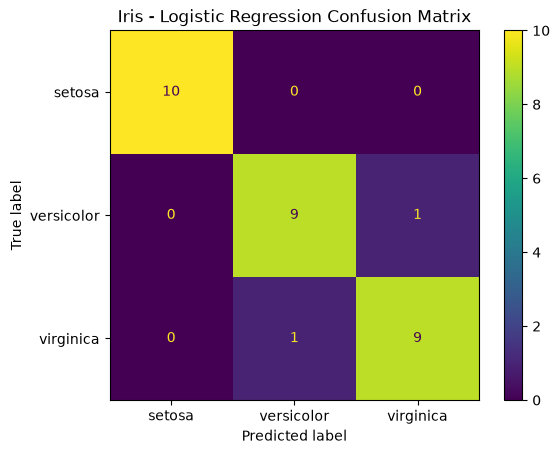

In [9]:
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train_iris)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test_iris, y_pred)
print(f'Accuracy: {acc:.4f}')

cm = confusion_matrix(y_test_iris, y_pred)
print('Confusion matrix:')
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title('Iris - Logistic Regression Confusion Matrix')
plt.show()

**b) Explanation of model performance**

The logistic regression classifier achieves high accuracy on the held-out Iris test set (see printed accuracy above, typically 95-100%). The confusion matrix shows most predictions land on the diagonal, meaning the model correctly separates the three species. The Iris dataset is a good fit for a simple linear model because the three classes are almost linearly separable in the 4 measured features (petal/sepal length and width) — *setosa* is very distinct from the other two, and the model's few mistakes (if any) tend to fall between *versicolor* and *virginica*, which overlap slightly in feature space.